# An Explorative Analysis of the Game of Chess - First Project Milestone

## 1. Project Description

The game of chess is an incredibly fascinating, yet deceptively simple, game. With only six unique pieces, each constrained to a number of legal moves on a small 8x8 grid, the game may seem trivial. Yet, chess remains infinitely complex, boasting an estimated 10^120 unique games. This extensive replayability and strategy behind the game has allowed chess to withstand the test of time, being played for over a thousand years all the way into the digital age. And this is where our project motivation stems from: chess in the modern day. Because the game is so popular, there are multiple robust datasets of online chess games publicly available. These datasets provide everything from the game winner, to the moves that were made, to the rating (ELO) of the players. Having this much accessible data would allow for extensive statistical analysis, revealing new trends in the digital era or retention of old reliable strategies to this day. Additionally, the implementation of chess engines, such as Stockfish, may prove interesting in effectively analyzing strategies and game state evaluations. We aim to study a dataset of games from the public chess platform Lichess in the hopes of discovering such patterns.

## 2. Summary of Accomplishments

For this milestone, research questions were refined, methods were developed, and preliminary results were gathered for our dataset. This notebook includes basic information about the project, ethical considerations, findings, descriptions of the tasks accomplished, future directions (milestones), and how/why the research questions were refined during the development process.

The following milestones from the proposal were completed:

- Dataset acquisition
- Dataset cleaning
- Preliminary plots and visualization

## 3. Ethical Concerns

From our stakeholder analysis in our proposal, we identified four different stakeholders in our project. The following list outlines these stakeholders and the harm mitigation steps taken to reduce the harm of our project.

#### 3.1. Lichess players

- We are directly analyzing this group's data.
- It is possible that conclusions drawn from this dataset could harm players. For instance, if a specific game is analyzed, bad actors could cyberbully the players in that game for their playstyle.
  - To prevent this from happening, we never analyze a singular game of chess. Data is processed and aggregated into tables, plots, and diagrams
  - Furthermore, harm is mitigated by dropping the player names/ids from the dataframe. This means that no player information will be exposed in this project.

#### 3.3. Lichess.org

- We are using Lichess.org's data for analysis.
- The harm that could come about from this is misrepresenting the community of Lichess or using their data in ways that they do not approve.
  - For the analysis done for this project, we are well within the guidelines for fair use of their data.
  - Lichess.org states: "Database exports are released under the Creative Commons CC0 license. Use them for research, commercial purpose, publication, anything you like. You can download, modify and redistribute them, without asking for permission."

#### 3.4. Larger Chess Player Community

- These stakeholders could use and study the models developed in this project in order to sharpen their game.
- If incorrect conclusions are drawn from this dataset, it could cause players to adopt unhelpful strategies in their gameplay.
  - Mitigation of this can be seen in section 5.
  - We make it clear that we are not experts, and the conclusions drawn are not necessarily 100% accurate.
- It is possible that the conclusions drawn from this project could be used to assign stereotypes to players of different ELOs.
  - In our language, we never use ELO to say anything about individual or groups personally. Our verbiage makes it clear that we are only analyzing chess gameplay and not IQ/intelligence of players.
  - The aim of this project is to analyze chess games for the purpose of exploration. Conclusions that may imply certain stereotypes are not made in bad faith.

#### 3.5. Chess Coaches and Tournament Players (Competitive Chess)

- This group could study the models and analysis done in this project to become better at either coaching or playing chess.
- If incorrect conclusions are drawn from this dataset, players or coaches may adopt unhelpful strategies in their gameplay and teaching. This risk level is especially concerning for this group because they have made a career out of chess.
  - Risk mitigation of this is stated in disclaimer in section 5.
  - We make it clear that we are not experts, and the conclusions drawn are not necessarily 100% accurate.

## 4. Methods

#### 4.1. Refinements to the Research Questions

Once the team began to explore the data and play with the different features and properties, new research questions began to formulate. It became clear that there were several prominent categories available for analysis in the game of chess, such as player characteristics (ELO), game outcomes, and game state analyses. These categories are not completely distinct and all potentially bring useful insight on understanding the multifaceted layers of chess.

Here is the refined list of research questions broken into logical categories:

1. Chess Opening Analysis
   - What are the most popular openings at each player ELO?
   - Are certain openings better (i.e. higher win rate) for beginners/experts?
   - Are some openings more "advanced" than others?
2. Chess Piece Analysis
   - Which pieces are moved the most each game?
   - Which pieces most commonly survive the longest each game?
   - Does survival of certain pieces increase likelihood of victory?
   - Does player ELO affect any of the previous questions?
3. Chess Board Analysis
   - What are the most travelled-to/"important" squares in each game?
   - Does this change based on current game state (early, middle, late)?
   - Does player ELO affect any of the prvious questions?
4. Player ELO Analysis
   - Can game winner be estimated from some combination of variables?
   - Can player ELO be accurately estimated from the list of moves?

#### 4.2. High Level Description of Methods

More detail of the analysis steps can be drawn from the well commented code in this notebook, but following is an overview of the steps taken to process, analyze, and plot the data.

4.2.1 Data Acquisition

- Data was downloaded from Kaggle. This is the link to the dataset used: https://www.kaggle.com/datasets/datasnaek/chess/data
- Downloaded as a CSV
- Dataset includes: - Game ID; - Rated (T/F); - Start Time; - End Time; - Number of Turns; - Game Status; - Winner; - Time Increment; - White Player ID; - White Player Rating; - Black Player ID; - Black Player Rating; - All Moves in Standard Chess Notation; - Opening Eco (Standardised Code for any given opening, list here); - Opening Name; - Opening Ply (Number of moves in the opening phase)

  4.2.2 Data Cleaning

- Player and game ids were dropped to comply with section 3.1.
- Non-rated games were dropped for rating analysis.
- Categorical data was assigned to numeric values:

  - Winner data was assigned to -1, 0, and 1 for black wins, draw, and white wins respectively.
  - Game ending data was assigned to 0, 1, 2, 3 for resigns, mates, draws, and timeouts respectively.
  - Moves were separated into arrays.
  - Game rating data was added as average ELO of both players.

    4.2.3 Data Exploration

- (correlation matrix?)
- (histograms?)
- (heatmaps?)

## 5. Disclaimer

The team members on this project are by no means chess experts. We are casual enjoyers of the game. With that said, the conclusions drawn from this dataset may be flawed due to lack of expertise. All the code used to analyze, plot, and develop models is available in this notebook (and external modules clearly outlined). This transparency allows for an observer to draw their own conclusions about the validity of our conclusions.

## 6. Preliminary Code and Results

This section is broken up into five categories

1. Preliminary Data Exploration
2. Chess Opening Analysis
3. Chess Board Analysis
4. Chess Player ELO Analysis


In [18]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import chess
from stockfish import Stockfish

#### 1. Preliminary Data Exploration


In [2]:
# Import data and observe shape and columns
chess_data_raw = pd.read_csv("data/games.csv")
print(chess_data_raw.shape)
print(chess_data_raw.columns)
chess_data_raw.head()

(20058, 16)
Index(['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status',
       'winner', 'increment_code', 'white_id', 'white_rating', 'black_id',
       'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply'],
      dtype='object')


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [3]:
# Data Cleaning
chess_data = chess_data_raw.drop(columns=["id", "white_id", "black_id"])
chess_data = chess_data.dropna()

# Drop all non-rated games for doing rating analysis
chess_data = chess_data[chess_data["rated"] == True]
# Remove rated, created at, and last move at columns
chess_data = chess_data.drop(["rated","created_at","last_move_at"],axis=1)
# Map winner column
chess_data["winner"] = chess_data["winner"].map({"black": -1, "white": 1}).fillna(0)
# Map victory column
chess_data["victory_status"] = chess_data["victory_status"].map({"resign": 0, "mate": 1,"draw": 2, "outoftime": 3})
# Convert moves column to array of moves
chess_data["moves"] = chess_data["moves"].str.split(" ")
# Add column for average player ELO per game
chess_data["game_rating"] = (chess_data["white_rating"] + chess_data["black_rating"]) / 2
# Add column to bucket games by rating 
chess_data["rating_bucket"] = pd.cut(
    chess_data["game_rating"],
    bins=3,
    labels=["low", "medium", "high"]
)

chess_data.head()

,turns,victory_status,winner,increment_code,white_rating,black_rating,moves,opening_eco,opening_name,opening_ply,game_rating,rating_bucket
1,16,0,-1.0,5+10,1322,1261,"[d4, Nc6, e4, e5, f4, f6, dxe5, fxe5, fxe5, Nx...",B00,Nimzowitsch Defense: Kennedy Variation,4,1291.5,low
2,61,1,1.0,5+10,1496,1500,"[e4, e5, d3, d6, Be3, c6, Be2, b5, Nd2, a5, a4...",C20,King's Pawn Game: Leonardis Variation,3,1498.0,medium
3,61,1,1.0,20+0,1439,1454,"[d4, d5, Nf3, Bf5, Nc3, Nf6, Bf4, Ng4, e3, Nc6...",D02,Queen's Pawn Game: Zukertort Variation,3,1446.5,medium
4,95,1,1.0,30+3,1523,1469,"[e4, e5, Nf3, d6, d4, Nc6, d5, Nb4, a3, Na6, N...",C41,Philidor Defense,5,1496.0,medium
6,33,0,1.0,10+0,1520,1423,"[d4, d5, e4, dxe4, Nc3, Nf6, f3, exf3, Nxf3, N...",D00,Blackmar-Diemer Gambit: Pietrowsky Defense,10,1471.5,medium


Players of Black Ratings ---------------
Mean: 1593.5031878675334
Median: 1573.0

Players of White Ratings ---------------
Mean: 1597.1020117610647
Median: 1577.0

All Player Ratings ---------------
Mean: 1595.302599814299
Median: 1575.0



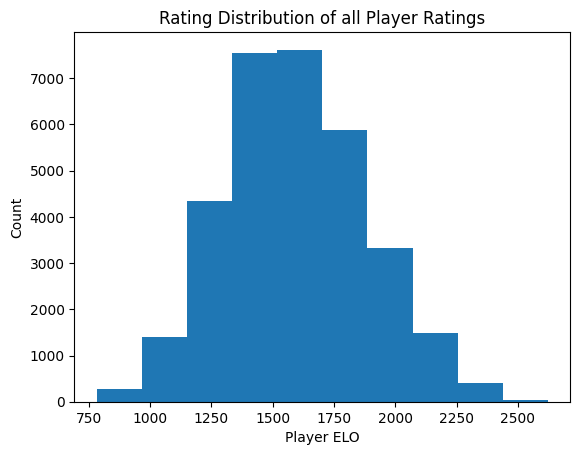

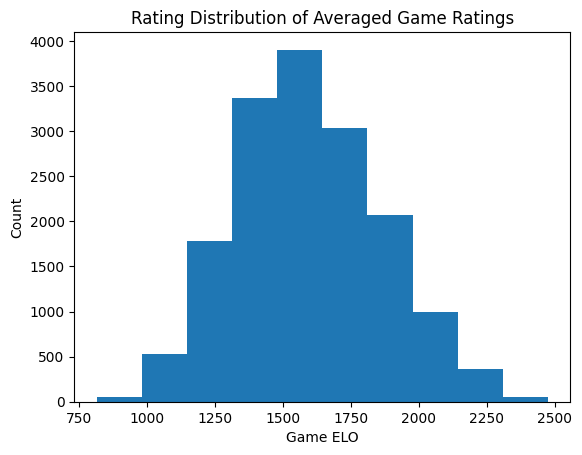

In [10]:
# Preliminary Data
print("Players of Black Ratings ---------------")
print("Mean:", chess_data["black_rating"].mean())
print("Median:", chess_data["black_rating"].median())
print()
print("Players of White Ratings ---------------")
print("Mean:", chess_data["white_rating"].mean())
print("Median:", chess_data["white_rating"].median())
print()
# Make array with every player (both black or white)
all_players = pd.concat([chess_data['white_rating'], chess_data['black_rating']], ignore_index=True)
print("All Player Ratings ---------------")
print("Mean:", all_players.mean())
print("Median:", all_players.median())
print()

# Visualization of rating distribution
plt.hist(all_players)
plt.title("Rating Distribution of all Player Ratings")
plt.xlabel("Player ELO")
plt.ylabel("Count")
plt.show()
plt.hist(chess_data['game_rating'])
plt.title("Rating Distribution of Averaged Game Ratings")
plt.xlabel("Game ELO")
plt.ylabel("Count")
plt.show()

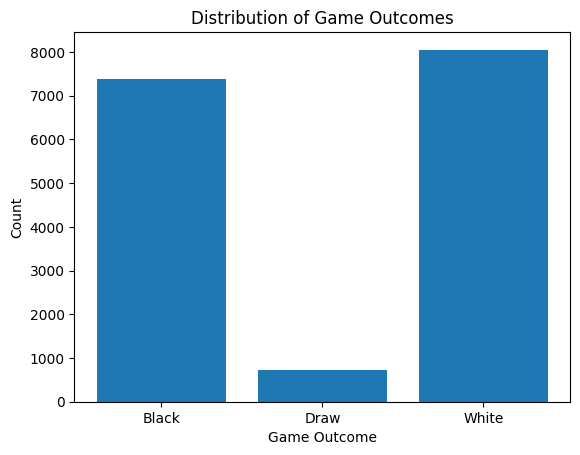

In [13]:
# Count occurrences of each outcome
counts = chess_data['winner'].value_counts().sort_index()

# Ensure order: Black (-1), Draw (0), White (1)
counts = counts.reindex([-1, 0, 1])

# Map labels
labels = ['Black', 'Draw', 'White']

# Plot
plt.figure()
plt.bar(labels, counts)
plt.title('Distribution of Game Outcomes')
plt.xlabel('Game Outcome')
plt.ylabel('Count')
plt.show()

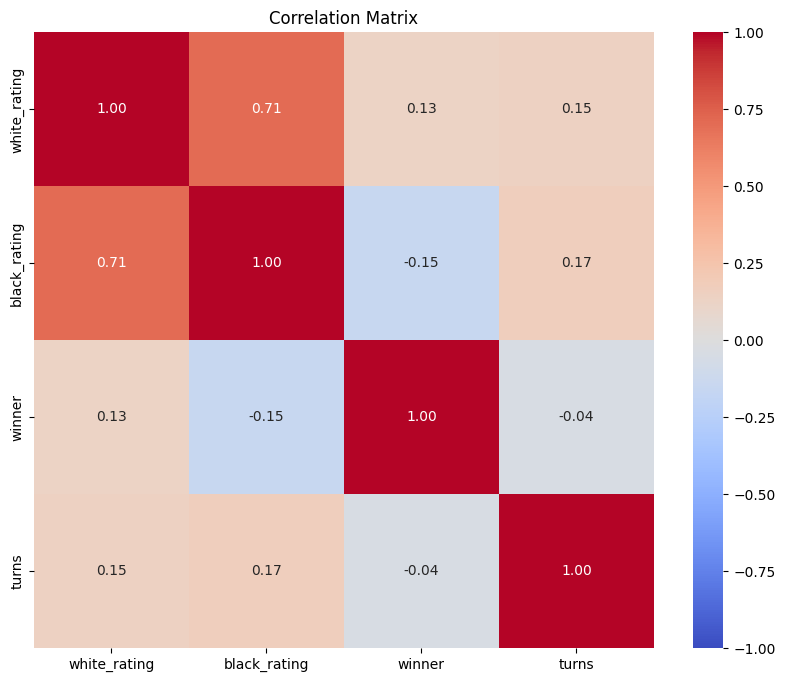

In [14]:
# Correlation matrix
chess_corr_data = chess_data[["white_rating", "black_rating", "winner", "turns"]]

corr_matrix = chess_corr_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmax=1, vmin=-1)
plt.title("Correlation Matrix")
plt.show()

#### 2. Chess Opening Analysis


In [16]:
# Get most popular opening for each rating block
def getOpeningPopularity(block,n):
      if block == "all":
            sample = chess_data
      else:
            sample = chess_data[chess_data["rating_bucket"]==block]
      eco_stats = sample.groupby("opening_eco").agg(
            white_rating_mean=("white_rating", "mean"),
            white_rating_std=("white_rating", "std"),
            black_rating_mean=("black_rating", "mean"),
            black_rating_std=("black_rating", "std"),
            count=("opening_eco", "size"),
            winner=("winner", "mean"),
      )
      most_popular = eco_stats.nlargest(n, "count")
      least_popular = eco_stats[eco_stats["count"] == 1]
      print("\n==========\n"
            f"Most Popular Opening for {block.capitalize()} Rating (ELO {sample["game_rating"].min()} - {sample["game_rating"].max()}):")
      print(most_popular)

getOpeningPopularity("all",10)
getOpeningPopularity("low",3)
getOpeningPopularity("medium",3)
getOpeningPopularity("high",3)


Most Popular Opening for All Rating (ELO 816.5 - 2475.5):
             white_rating_mean  white_rating_std  black_rating_mean  \
opening_eco                                                           
A00                1436.684145        270.479128        1490.149813   
C00                1566.980743        260.836707        1547.447043   
D00                1528.164154        283.840973        1551.050251   
B01                1532.117547        289.958197        1526.860307   
C41                1533.804618        240.503144        1494.978686   
C20                1385.660448        206.730201        1401.283582   
A40                1585.581213        299.697182        1547.181996   
B20                1538.226293        262.212967        1606.303879   
B00                1538.214286        271.199328        1476.448052   
C50                1560.594406        250.152614        1553.025641   

             black_rating_std  count    winner  
opening_eco                            

Average number of turns
61.96255029402662


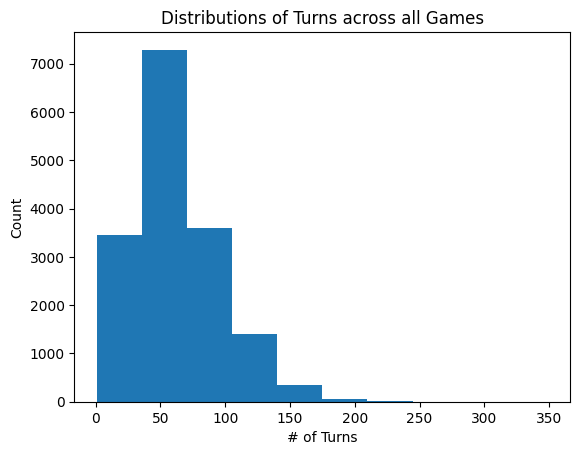

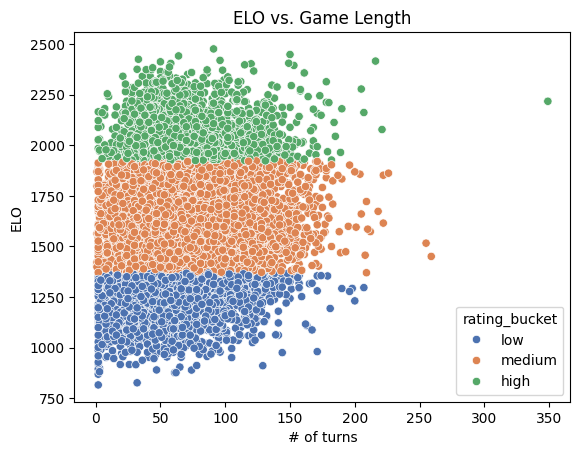

In [17]:
# Turns Visualization
print("Average number of turns")
print(chess_data['turns'].mean())

plt.hist(chess_data['turns'])
plt.title("Distributions of Turns across all Games")
plt.xlabel("# of Turns")
plt.ylabel("Count")
plt.show()

sns.scatterplot(x=chess_data["turns"], y=chess_data["game_rating"], hue=chess_data["rating_bucket"], palette="deep")
plt.title("ELO vs. Game Length")
plt.xlabel("# of turns")
plt.ylabel("ELO")
plt.show()

#### 3. Chess Board Analysis


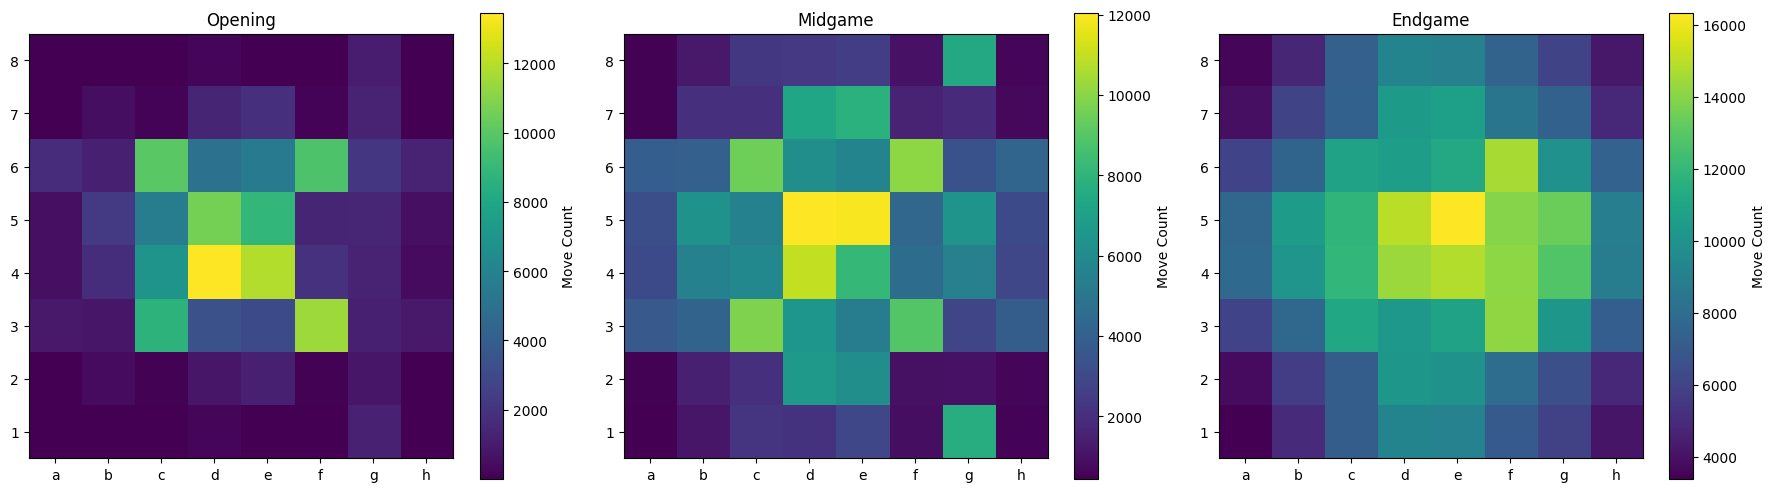

In [20]:
# Chess board heatmap
def iterate_heatmap_from_moves(moves, board, heatmap):
    for san in moves:
        try:
            move = board.parse_san(san)
        except:
            break  # skip invalid games
        
        square = move.to_square
        
        # Convert square index → row, col
        row = 7 - chess.square_rank(square)
        col = chess.square_file(square)
        
        heatmap[row, col] += 1

        board.push(move)

stockfish_games = chess_data[chess_data["turns"] > 20]

# 8x8 board (rank 8 at top, rank 1 at bottom)
opening_heatmap = np.zeros((8, 8))
mid_game_heatmap = np.zeros((8, 8))
end_game_heatmap = np.zeros((8, 8))

for moves in stockfish_games["moves"]:
    board = chess.Board()

    if len(moves) > 30:
        opening = moves[:10]
        mid_game = moves[10:30]
        end_game = moves[30:]
    else:
        opening = moves[:10]
        mid_game = []
        end_game = moves[10:]

    iterate_heatmap_from_moves(opening, board, opening_heatmap)
    iterate_heatmap_from_moves(mid_game, board, mid_game_heatmap)
    iterate_heatmap_from_moves(end_game, board, end_game_heatmap)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

heatmaps = [opening_heatmap, mid_game_heatmap, end_game_heatmap]
titles = ["Opening", "Midgame", "Endgame"]

for ax, data, title in zip(axes, heatmaps, titles):
    im = ax.imshow(data)  # no shared vmin/vmax → independent scaling
    
    ax.set_xticks(range(8))
    ax.set_xticklabels(['a','b','c','d','e','f','g','h'])
    
    ax.set_yticks(range(8))
    ax.set_yticklabels(['8','7','6','5','4','3','2','1'])
    
    ax.set_title(title)
    
    # Individual colorbar per subplot
    plt.colorbar(im, ax=ax, label="Move Count")

plt.tight_layout()
plt.show()

#### 4. Chess Player ELO Analysis


## 7. Future Directions, Schedule, and Milestones

1. Finish preliminary analyses and descriptions on opening data.
2. Begin piece and board analyses.
3. Implement stockfish for in-depth game analysis.
4. Begin development on neural network for ELO prediction from moves.

#### Timeline:

- _Week 1 | March 1-7:_
  - _6: Submit Project Proposal_
  - _Initial database review_
- _Week 2 | March 8-14:_
  - _Begin preliminary data analysis_
  - _Research methods for board analysis and processing move data_
- _Week 3 | March 15-21:_
  - _19: Peer Feedback_
  - _Reworking question and methodology_
- _Week 4 | March 22-28:_
  - _27: Submit Project Milestone_
  - _Completion of preliminary data analysis_
  - _Begin development of neural network_
- Week 5 | March 29 - April 4:
  - 30-3: Staff Feedback
  - Finalize analyses to answer research question
- Week 6 | April 5-11:
  - Finish neural network
  - Begin report
- Week 7 | April 12-18:
  - 17: Final Project Report


# Rubric Stuff

- Project Desc
- Data Desc, acquisition, cleaning, exploration
- Ethical Data Concerns
- Methods
- Preliminary Results
- Peer Feedback
- Completed Milestones
- Methods milestones
- summary
- updated project schedule
- deviations from proposal
